# 04.1.1 — RoBERTa on Full-Concat Scrubbed+ Text

Identical training recipe to the RoBERTa winner from the 07 seed harness
(lr=2e-5, weighted CE, 12 epochs, early-stop patience 3, seed=42), but with
`text_full_concat_scrubbed_plus` as the input column.

This gives us the RoBERTa counterpart to 04.5 (ModernBERT scrubbed+).


In [1]:
import os
import re
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report,
    balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer, DataCollatorWithPadding,
    EarlyStoppingCallback, Trainer, TrainingArguments,
)
from transformers.utils.notebook import NotebookProgressCallback

RANDOM_STATE = 42
MIN_SAMPLES_PER_CLASS = 100
MODEL_CHECKPOINT = 'roberta-base'
TEXT_COLUMN = 'text_full_concat_scrubbed_plus'
MAX_LENGTH = 256

# RoBERTa winner from the 07 seed harness
BEST_LR = 2e-5
USE_CLASS_WEIGHTS = True

NUM_TRAIN_EPOCHS = 12
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
GRAD_ACCUM_STEPS = 2
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.06
EARLY_STOP_PATIENCE = 3
USE_FP16 = True

OUTPUT_DIR_ROOT = 'artifacts/origin_finetuning_roberta_fulltext_scrubbed_plus'
os.makedirs(OUTPUT_DIR_ROOT, exist_ok=True)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_STATE)


Device: cuda


## Scrubbing vocabulary

In [2]:
# Scrubbing vocabulary: countries + region aliases + cultivars + producer context
# Lifted from 04.5 so that 02.1 / 03.1 / 04.1.1 / 06.1 / 07.1 are a fair comparison.
COUNTRY_TERMS = {
    "Ethiopia": ["ethiopia", "ethiopian"],
    "Colombia": ["colombia", "colombian", "columbian"],
    "Panama": ["panama", "panamanian"],
    "Kenya": ["kenya", "kenyan"],
    "Indonesia": ["indonesia", "indonesian"],
    "Guatemala": ["guatemala", "guatemalan"],
    "Costa Rica": ["costa rica", "costa rican", "costarican"],
    "El Salvador": ["el salvador", "salvadoran", "salvadorean", "salvadorian"],
    "Rwanda": ["rwanda", "rwandan"],
    "Brazil": ["brazil", "brazilian"],
    "Honduras": ["honduras", "honduran"],
    "Peru": ["peru", "peruvian"],
    "Taiwan": ["taiwan", "taiwanese"],
    "Papua New Guinea": ["papua new guinea", "papua new guinean"],
    "Nicaragua": ["nicaragua", "nicaraguan"],
    "Burundi": ["burundi", "burundian"],
    "Thailand": ["thailand", "thai"],
    "India": ["india", "indian"],
    "Mexico": ["mexico", "mexican"],
    "Tanzania": ["tanzania", "tanzanian"],
    "Yemen": ["yemen", "yemeni"],
    "Ecuador": ["ecuador", "ecuadorian"],
    "Bolivia": ["bolivia", "bolivian"],
    "Jamaica": ["jamaica", "jamaican"],
    "Uganda": ["uganda", "ugandan"],
    "Dominican Republic": ["dominican republic", "dominican"],
    "Zambia": ["zambia", "zambian"],
    "China": ["china", "chinese"],
    "Vietnam": ["vietnam", "vietnamese"],
    "Philippines": ["philippines", "philippine", "filipino"],
    "Malaysia": ["malaysia", "malaysian"],
    "Laos": ["laos", "laotian"],
    "Zimbabwe": ["zimbabwe", "zimbabwean"],
    "Haiti": ["haiti", "haitian"],
    "Puerto Rico": ["puerto rico", "puerto rican", "puertorican"],
    "Nepal": ["nepal", "nepalese", "nepali"],
    "Myanmar": ["myanmar", "burmese"],
    "Cameroon": ["cameroon", "cameroonian"],
    "Australia": ["australia", "australian"],
    "South Africa": ["south africa", "south african"],
    "Malawi": ["malawi", "malawian"],
    "Venezuela": ["venezuela", "venezuelan", "merida state", "mocoties valley"],
    "Timor-Leste": ["east timor", "timor leste", "timorese"],
    "DR Congo": ["democratic republic of the congo", "dr congo", "congo", "congolese"],
    "United Kingdom": ["united kingdom", "british", "pitcairn island", "saint helena", "st helena", "sandy bay valley"],
    "United States": [
        "usa", "united states", "american",
        "hawaii", "hawai'i", "hawaiian", "hawaii island",
        "big island", "kona", "puna district", "holualoa", "oahu", "maui", "kauai",
        "ka u", "ka'u", "kau",
    ],
}

REGION_ALIASES = {
    "Ethiopia": ["yirgacheffe", "sidamo", "sidama", "guji", "gedeb", "gedeo", "kochere", "hambela",
                 "shakiso", "jimma", "limu", "oromia", "harrar", "kaffa", "bench maji", "bench-maji",
                 "arbegona", "bensa"],
    "Colombia": ["huila", "cauca", "narino", "tolima", "quindio", "caldas", "risaralda", "antioquia",
                 "cundinamarca", "santander", "pitalito", "acevedo", "planadas", "gaitania", "piendamo",
                 "caicedonia", "san agustin", "armenia"],
    "Panama": ["boquete", "chiriqui", "volcan", "jaramillo", "alto quiel", "paso ancho",
               "piedra candela", "canas verdes", "silla del pando", "renacimiento"],
    "Kenya": ["nyeri", "kirinyaga", "kiambu", "embu", "muranga", "murang'a", "thika", "ruiru",
              "mathira", "meru", "nakuru", "gichugu", "karatina"],
    "Indonesia": ["sumatra", "aceh", "gayo", "lintong", "mandheling", "sidikalang", "toraja",
                  "sulawesi", "java", "bali", "kintamani", "flores", "kerinci"],
    "Guatemala": ["huehuetenango", "antigua", "acatenango", "fraijanes", "coban", "atitlan",
                  "chimaltenango", "quiche", "solola", "palencia", "sacatepequez", "san marcos",
                  "hoja blanca", "cuilco"],
    "Costa Rica": ["tarrazu", "central valley", "west valley", "tres rios", "naranjo", "dota",
                   "poas", "alajuela", "brunca", "turrialba", "coto brus", "chirripo"],
    "El Salvador": ["ahuachapan", "chalatenango", "apaneca", "ilamatepec", "santa ana",
                    "el boqueron", "quetzaltepec", "juayua", "ataco"],
    "Rwanda": ["gakenke", "nyamasheke", "karongi", "huye", "nyamagabe", "rulindo", "gikongoro",
               "lake kivu"],
    "Brazil": ["cerrado", "mogiana", "minas gerais", "mantiqueira", "sul de minas",
               "chapada diamantina", "carmo de minas"],
    "Honduras": ["marcala", "copan", "ocotepeque", "comayagua", "intibuca", "santa barbara",
                 "el paraiso", "capucas"],
    "Peru": ["cajamarca", "jaen", "san ignacio", "chanchamayo", "cusco", "villa rica", "oxapampa",
             "junin", "puno"],
    "Taiwan": ["alishan", "yunlin", "chiayi", "chia yi", "nantou", "taichung", "pingtung"],
    "Papua New Guinea": ["wahgi valley", "western highlands", "eastern highlands", "jiwaka",
                         "kainantu", "okapa"],
    "Nicaragua": ["jinotega", "matagalpa", "nueva segovia", "madriz", "ocotal", "dipilto"],
    "Burundi": ["kayanza", "ngozi", "muramvya", "muyinga", "bururi"],
    "Thailand": ["chiang rai", "doi chang", "doi pangkhon", "chiang mai", "nan province"],
    "India": ["coorg", "chikmagalur", "karnataka", "bababudangiri", "nilgiris"],
    "Mexico": ["chiapas", "oaxaca", "veracruz", "coatepec", "pluma hidalgo"],
    "Tanzania": ["mbeya", "ruvuma", "ngorongoro", "arusha", "kilimanjaro", "mbozi"],
    "Yemen": ["haraaz", "haraz", "sanaa", "bani matar", "hayma"],
    "Ecuador": ["loja", "pichincha", "imbabura", "zamora", "chimborazo", "saraguro"],
    "Bolivia": ["caranavi", "yungas", "la paz"],
    "Jamaica": ["blue mountain", "blue mountains"],
    "Uganda": ["rwenzori", "bugisu", "sipi falls"],
    "Vietnam": ["lam dong", "quang tri", "dalat", "cau dat"],
    "Philippines": ["benguet", "bukidnon", "davao"],
    "China": ["yunnan", "baoshan", "puer", "pu'er", "lincong"],
    "Puerto Rico": ["utuado", "yauco", "adjuntas"],
    "Venezuela": ["mocoties valley", "merida state"],
    "Malawi": ["malawi"],
}

REGION_ONLY_TERMS = [
    "central america", "south america", "latin america",
    "east africa", "central africa", "west africa", "africa",
    "asia", "the americas", "americas",
    "central and south america", "south and central america",
    "east and central africa", "various africa growing regions",
]

CULTIVAR_TERMS = [
    "sl28", "sl-28", "sl 28", "sl34", "sl-34", "sl 34",
    "ruiru 11", "ruiru-11", "batian", "k7",
    "gesha", "geisha",
    "pacamara", "pache", "villa sarchi",
    "bourbon", "pink bourbon", "yellow bourbon", "red bourbon",
    "caturra", "catuai", "catuai vermelho", "catuai amarelo",
    "typica", "mundo novo",
    "maragogipe", "maragogype", "maracaturra",
    "castillo", "colombia variety", "variedad colombia", "tabi",
    "heirloom", "ethiopian heirloom",
    "tim tim", "s795", "ateng",
    "catimor", "sarchimor", "icatu", "obata",
]

PRODUCER_CONTEXT_TERMS = [
    "finca", "hacienda", "beneficio",
    "cup of excellence",
    "washing station", "wet mill",
    "best of panama",
]

all_scrub_terms = []
for v in COUNTRY_TERMS.values():    all_scrub_terms.extend(v)
for v in REGION_ALIASES.values():   all_scrub_terms.extend(v)
all_scrub_terms.extend(REGION_ONLY_TERMS)
all_scrub_terms.extend(CULTIVAR_TERMS)
all_scrub_terms.extend(PRODUCER_CONTEXT_TERMS)
all_scrub_terms = sorted(set(all_scrub_terms), key=len, reverse=True)
print(f'Loaded {len(all_scrub_terms)} scrub terms')

SCRUB_PATTERN = re.compile(
    r'\b(' + '|'.join(re.escape(t) for t in all_scrub_terms) + r')\b',
    flags=re.IGNORECASE,
)

def scrub(text):
    if not isinstance(text, str) or not text:
        return ''
    return SCRUB_PATTERN.sub(' [ORIGIN] ', text)


Loaded 403 scrub terms


## Build text column

In [3]:
# Concat Blind Assessment + Notes + Who Should Drink It + Bottom Line, then scrub
def minimal_raw_text(text):
    text = '' if pd.isna(text) else str(text)
    return re.sub(r'\s+', ' ', text).strip().lower()

def normalize_text_keep_brackets(text):
    text = minimal_raw_text(text)
    text = re.sub(r'[^a-z0-9\s\[\]]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

EXTRA_TEXT_COLS = ['Blind Assessment', 'Notes', 'Who Should Drink It', 'Bottom Line']

def concat_and_scrub(row):
    pieces = []
    for col in EXTRA_TEXT_COLS:
        v = row[col]
        if pd.notna(v) and str(v).strip():
            raw = minimal_raw_text(v)
            scrubbed = scrub(raw)
            cleaned = normalize_text_keep_brackets(scrubbed)
            pieces.append(cleaned)
    return ' '.join(p for p in pieces if p)

df = pd.read_csv('Data/final_coffee_reviews.csv')
df['text_full_concat_scrubbed_plus'] = df.apply(concat_and_scrub, axis=1)
df['text_raw_minimal'] = df['Blind Assessment'].fillna('').map(minimal_raw_text)
df['origin_country'] = df['Country'].astype('string').str.strip().replace('', pd.NA)

work = df[(df['text_raw_minimal'].str.len() >= 30) & (df['origin_country'].notna())].copy()
counts = work['origin_country'].value_counts()
valid_classes = counts[counts >= MIN_SAMPLES_PER_CLASS].index
work = work[work['origin_country'].isin(valid_classes)].copy().reset_index(drop=True)

# Leakage audit
def contains_own_country(row):
    t = row['text_full_concat_scrubbed_plus'].lower()
    c = str(row['origin_country']).lower()
    return c in t if c and t else False
work['leaks_country'] = work.apply(contains_own_country, axis=1)
leak_rate = float(work['leaks_country'].mean())

print(f'Rows: {len(work)} | Classes: {work["origin_country"].nunique()}')
print(f'Avg scrubbed+ text length (chars): {int(work["text_full_concat_scrubbed_plus"].str.len().mean())}')
print(f'Country-name leakage: {leak_rate:.1%}  (target: <2%)')


Rows: 6820 | Classes: 15
Avg scrubbed+ text length (chars): 875
Country-name leakage: 0.8%  (target: <2%)


## 70/15/15 stratified split

In [4]:
# Same 70/15/15 stratified split as the rest of the pipeline
y = work['origin_country']
row_idx = work.index
train_idx, temp_idx, y_train, y_temp = train_test_split(
    row_idx, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)
print('Train/Val/Test:', len(train_idx), len(val_idx), len(test_idx))


Train/Val/Test: 4774 1023 1023


## Labels + class weights

In [5]:
label_names = sorted(work['origin_country'].unique())
label2id = {label: idx for idx, label in enumerate(label_names)}
id2label = {idx: label for label, idx in label2id.items()}

train_texts = work.loc[train_idx, TEXT_COLUMN].fillna('').tolist()
val_texts   = work.loc[val_idx,   TEXT_COLUMN].fillna('').tolist()
test_texts  = work.loc[test_idx,  TEXT_COLUMN].fillna('').tolist()
train_labels = work.loc[train_idx, 'origin_country'].map(label2id).tolist()
val_labels   = work.loc[val_idx,   'origin_country'].map(label2id).tolist()
test_labels  = work.loc[test_idx,  'origin_country'].map(label2id).tolist()

class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(label_names)),
    y=np.array(train_labels),
)
class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float)


## Tokenize + dataset

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

class CoffeeOriginDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.encodings = tokenizer(texts, truncation=True, max_length=max_length, padding=False)
        self.labels = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = CoffeeOriginDataset(train_texts, train_labels, tokenizer, MAX_LENGTH)
val_dataset   = CoffeeOriginDataset(val_texts,   val_labels,   tokenizer, MAX_LENGTH)
test_dataset  = CoffeeOriginDataset(test_texts,  test_labels,  tokenizer, MAX_LENGTH)
print('Train/Val/Test:', len(train_dataset), len(val_dataset), len(test_dataset))


Train/Val/Test: 4774 1023 1023


## Metrics + WeightedTrainer + run_one

In [7]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    return {
        'accuracy': accuracy_score(labels, preds),
        'balanced_accuracy': balanced_accuracy_score(labels, preds),
        'precision_macro': precision,
        'recall_macro': recall,
        'f1_macro': f1,
    }

class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.get('logits')
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

def build_training_args(output_dir, learning_rate):
    return TrainingArguments(
        output_dir=output_dir,
        learning_rate=learning_rate,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM_STEPS,
        num_train_epochs=NUM_TRAIN_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        eval_strategy='epoch',
        save_strategy='epoch',
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        greater_is_better=True,
        logging_strategy='epoch',
        disable_tqdm=True,
        report_to='none',
        fp16=USE_FP16 and torch.cuda.is_available(),
        seed=RANDOM_STATE,
    )

def run_one(learning_rate, use_class_weights, tag):
    set_seed(RANDOM_STATE)
    out_dir = os.path.join(OUTPUT_DIR_ROOT, tag)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_CHECKPOINT,
        num_labels=len(label_names), id2label=id2label, label2id=label2id,
    )
    args = build_training_args(out_dir, learning_rate)
    trainer_cls = WeightedTrainer if use_class_weights else Trainer
    extra = dict(class_weights=class_weights_tensor) if use_class_weights else {}
    trainer = trainer_cls(
        model=model, args=args,
        train_dataset=train_dataset, eval_dataset=val_dataset,
        processing_class=tokenizer, data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PATIENCE)],
        **extra,
    )
    try: trainer.remove_callback(NotebookProgressCallback)
    except Exception: pass
    print(f'\n=== Training {tag} | lr={learning_rate} | weighted={use_class_weights} ===')
    train_out = trainer.train()
    val_metrics  = trainer.evaluate(eval_dataset=val_dataset)
    test_metrics = trainer.evaluate(eval_dataset=test_dataset, metric_key_prefix='test')
    return trainer, train_out, val_metrics, test_metrics


## Train with the RoBERTa winning config

In [8]:
tag = f'scrubbed_plus_lr{BEST_LR:.0e}_weighted_seed{RANDOM_STATE}'
trainer_trained, train_out, val_m, test_m = run_one(
    BEST_LR, use_class_weights=USE_CLASS_WEIGHTS, tag=tag,
)

headline = {
    'tag': tag,
    'lr': BEST_LR,
    'weighted': USE_CLASS_WEIGHTS,
    'seed': RANDOM_STATE,
    'val_f1_macro': val_m['eval_f1_macro'],
    'val_balanced_accuracy': val_m['eval_balanced_accuracy'],
    'val_accuracy': val_m['eval_accuracy'],
    'test_f1_macro': test_m['test_f1_macro'],
    'test_balanced_accuracy': test_m['test_balanced_accuracy'],
    'test_accuracy': test_m['test_accuracy'],
    'post_scrub_leakage_rate': leak_rate,
}
print()
print(json.dumps(headline, indent=2))


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



=== Training scrubbed_plus_lr2e-05_weighted_seed42 | lr=2e-05 | weighted=True ===
{'loss': '5.362', 'grad_norm': '20.11', 'learning_rate': '1.954e-05', 'epoch': '1'}
{'eval_loss': '2.397', 'eval_accuracy': '0.3402', 'eval_balanced_accuracy': '0.192', 'eval_precision_macro': '0.2622', 'eval_recall_macro': '0.192', 'eval_f1_macro': '0.1505', 'eval_runtime': '1.504', 'eval_samples_per_second': '680', 'eval_steps_per_second': '21.27', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '4.049', 'grad_norm': '37.6', 'learning_rate': '1.778e-05', 'epoch': '2'}
{'eval_loss': '1.719', 'eval_accuracy': '0.5239', 'eval_balanced_accuracy': '0.4648', 'eval_precision_macro': '0.4429', 'eval_recall_macro': '0.4648', 'eval_f1_macro': '0.4102', 'eval_runtime': '1.533', 'eval_samples_per_second': '667.4', 'eval_steps_per_second': '20.88', 'epoch': '2'}


...

{'train_runtime': '407.8', 'train_samples_per_second': '140.5', 'train_steps_per_second': '4.414', 'train_loss': '1.965', 'epoch': '12'}


There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

{'eval_loss': '1.458', 'eval_accuracy': '0.7195', 'eval_balanced_accuracy': '0.6313', 'eval_precision_macro': '0.6205', 'eval_recall_macro': '0.6313', 'eval_f1_macro': '0.6235', 'eval_runtime': '1.689', 'eval_samples_per_second': '605.7', 'eval_steps_per_second': '18.95', 'epoch': '12'}


early stopping required metric_for_best_model, but did not find eval_f1_macro so early stopping is disabled


{'test_loss': '1.251', 'test_accuracy': '0.7312', 'test_balanced_accuracy': '0.6668', 'test_precision_macro': '0.63', 'test_recall_macro': '0.6668', 'test_f1_macro': '0.645', 'test_runtime': '1.486', 'test_samples_per_second': '688.5', 'test_steps_per_second': '21.54', 'epoch': '12'}

{
  "tag": "scrubbed_plus_lr2e-05_weighted_seed42",
  "lr": 2e-05,
  "weighted": true,
  "seed": 42,
  "val_f1_macro": 0.6235406464578617,
  "val_balanced_accuracy": 0.6313075450366662,
  "val_accuracy": 0.7194525904203324,
  "test_f1_macro": 0.6450332463723117,
  "test_balanced_accuracy": 0.666833272768961,
  "test_accuracy": 0.7311827956989247,
  "post_scrub_leakage_rate": 0.007624633431085044
}


## Per-class report and confusion matrix

== Test headline ==
Macro-F1:          0.6450
Balanced Accuracy: 0.6668
Accuracy:          0.7312

               precision    recall  f1-score   support

     Ethiopia      0.892     0.853     0.872       299
     Colombia      0.672     0.541     0.599       148
        Kenya      0.882     0.857     0.870       105
    Guatemala      0.635     0.643     0.639        84
    Indonesia      0.746     0.779     0.763        68
   Costa Rica      0.516     0.571     0.542        56
       Panama      0.754     0.868     0.807        53
United States      0.886     0.867     0.876        45
  El Salvador      0.524     0.611     0.564        36
       Brazil      0.556     0.667     0.606        30
       Rwanda      0.828     0.889     0.857        27
         Peru      0.350     0.350     0.350        20
    Nicaragua      0.360     0.474     0.409        19
     Honduras      0.500     0.500     0.500        18
       Mexico      0.348     0.533     0.421        15

     accuracy      

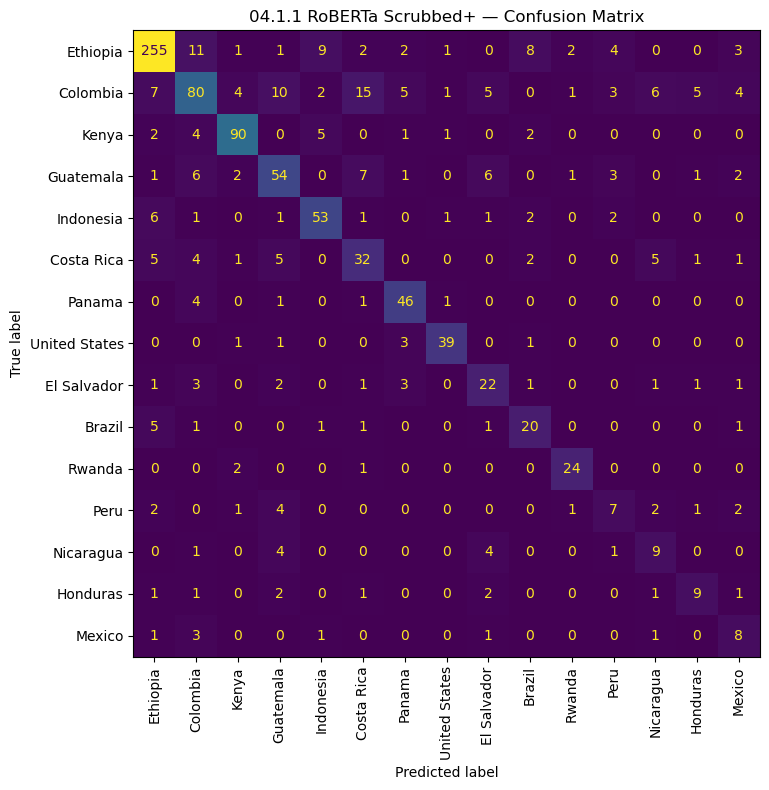

In [9]:
test_pred_output = trainer_trained.predict(test_dataset)
test_pred_ids = np.argmax(test_pred_output.predictions, axis=1)
test_true_labels = [id2label[i] for i in test_labels]
test_pred_labels = [id2label[i] for i in test_pred_ids]

class_order = work['origin_country'].value_counts().index.tolist()
print('== Test headline ==')
print(f'Macro-F1:          {f1_score(test_true_labels, test_pred_labels, average="macro", zero_division=0):.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_score(test_true_labels, test_pred_labels):.4f}')
print(f'Accuracy:          {accuracy_score(test_true_labels, test_pred_labels):.4f}')
print()
print(classification_report(test_true_labels, test_pred_labels, labels=class_order, zero_division=0, digits=3))

cm = confusion_matrix(test_true_labels, test_pred_labels, labels=class_order)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order).plot(
    ax=ax, xticks_rotation=90, colorbar=False,
)
plt.title('04.1.1 RoBERTa Scrubbed+ — Confusion Matrix')
plt.tight_layout()
plt.show()


## Save results

In [10]:
with open(os.path.join(OUTPUT_DIR_ROOT, 'results.json'), 'w') as f:
    json.dump({
        'notebook': '04.1.1_RoBERTa_FullText_Scrubbed_Plus',
        'model': MODEL_CHECKPOINT,
        'text_column': TEXT_COLUMN,
        'text_columns_used': EXTRA_TEXT_COLS,
        'scrub_tiers': ['countries_and_adjectivals', 'coffee_region_aliases', 'cultivars', 'producer_context_terms'],
        'num_scrub_terms': len(all_scrub_terms),
        'post_scrub_leakage_rate': leak_rate,
        'config': {
            'lr': BEST_LR, 'weighted': USE_CLASS_WEIGHTS,
            'epochs': NUM_TRAIN_EPOCHS, 'early_stop_patience': EARLY_STOP_PATIENCE,
            'seed': RANDOM_STATE, 'max_length': MAX_LENGTH,
        },
        'headline': headline,
    }, f, indent=2, default=float)
print('Saved', os.path.join(OUTPUT_DIR_ROOT, 'results.json'))


Saved artifacts/origin_finetuning_roberta_fulltext_scrubbed_plus\results.json
